# Result Analysis

In [76]:
import os

import pandas as pd
import matplotlib.pyplot as plt

In [77]:
age = pd.read_csv("../results/age_results_year.tsv", sep="\t", index_col=0)
race = pd.read_csv("../results/race_results_year.tsv", sep="\t", index_col=0)
gender = pd.read_csv("../results/gender_results_year.tsv", sep="\t", index_col=0)

## Gender

In [78]:
gender_year_acc = gender.groupby("years")["acc"].mean().reset_index()
gender_year_acc.rename(columns={"acc": "mean_acc"}, inplace=True)

print(gender_year_acc)

    years  mean_acc
0       0  0.446365
1       1  0.314483
2       5  0.231487
3      10  0.164527
4      20  0.120578
5      30  0.252789
6      40  0.246167
7      50  0.227990
8      60  0.177760
9      70  0.101867
10     80  0.104756
11     90  0.100186
12    100  0.173627


In [79]:
gender_grouped = (
    gender.groupby(["years", "severity"])["acc"]
    .mean()
    .reset_index()
    .rename(columns={"acc": "mean_acc"})
)

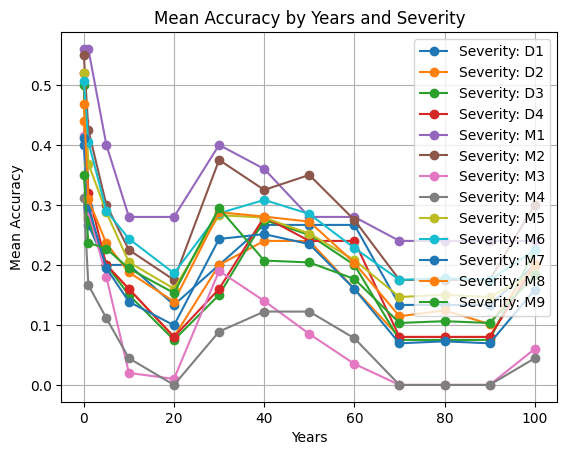

In [80]:
for sev in gender_grouped["severity"].unique():
    subset = gender_grouped[gender_grouped["severity"] == sev]
    plt.plot(subset["years"], subset["mean_acc"], marker="o", label=f"Severity: {sev}")

plt.xlabel("Years")
plt.ylabel("Mean Accuracy")
plt.title("Mean Accuracy by Years and Severity")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
fgender = pd.read_csv("../results/female_male_gender_results_year.tsv", sep="\t", index_col=0)

In [82]:
fgender_grouped = (
    fgender.groupby(["years", "severity"])["acc"]
    .mean()
    .reset_index()
    .rename(columns={"acc": "mean_acc"})
)

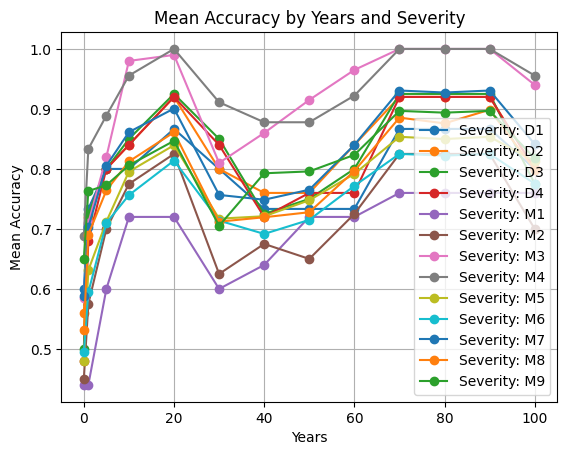

In [83]:
for sev in fgender_grouped["severity"].unique():
    subset = fgender_grouped[fgender_grouped["severity"] == sev]
    plt.plot(subset["years"], subset["mean_acc"], marker="o", label=f"Severity: {sev}")

plt.xlabel("Years")
plt.ylabel("Mean Accuracy")
plt.title("Mean Accuracy by Years and Severity")
plt.legend()
plt.grid(True)
plt.show()

## Age

In [84]:
age.columns

Index(['model', 'age_pair', 'years', 'type', 'severity', 'template_id', 'acc',
       'diff', 'expected', 'unexpected', 'macrodiff'],
      dtype='object')

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# Group data
age_heatmap_df = age.groupby(["age_pair", "years"])["acc"].mean().reset_index()

# Pivot for heatmap
heatmap_data = age_heatmap_df.pivot(index="age_pair", columns="years", values="acc")

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap="RdBu_r", center=0.5, annot=False)
plt.title("Sentencing Bias by Age Pair and Sentence Length (Mean acc)")
plt.xlabel("Sentence Length (Years)")
plt.ylabel("Age Pair")

os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/age_sentencing_bias_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved heatmap to ../assets/age_sentencing_bias_heatmap.png")

Saved heatmap to ../assets/age_sentencing_bias_heatmap.png


In [86]:
# Group by years, severity
age_sev = age.groupby(["years", "severity"])["acc"].mean().reset_index()

plt.figure(figsize=(7, 5))
for sev in sorted(age_sev["severity"].unique()):
    sub = age_sev[age_sev["severity"] == sev].sort_values("years")
    plt.plot(sub["years"], sub["acc"], marker="o", label=f"Severity {sev}")

plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Sentence Length (Years)")
plt.ylabel("Mean Accuracy (First Age Group More Likely)")
plt.title("Sentencing Bias by Sentence Length and Severity")
plt.legend()
plt.grid(True)

os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/age_bias_by_severity.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved line plot to ../assets/age_bias_by_severity.png")

Saved line plot to ../assets/age_bias_by_severity.png
